In [58]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
import os

In [59]:
# Import required libraries for downloading and extracting
import urllib.request
import zipfile
import os

# Dataset URL
url = "https://archive.ics.uci.edu/static/public/224/gas+sensor+array+drift+dataset.zip"

# File name to save
zip_path = "dataset.zip"

# Download the dataset
urllib.request.urlretrieve(url, zip_path)

print("Download complete.")

# Extract the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extraction complete.")

Download complete.
Extraction complete.


In [60]:
!ls dataset/

Dataset


In [61]:
import pandas as pd
import os

def parse_batch_file(filepath, batch_num):
    rows = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            parts = line.split()
            label = int(float(parts[0]))   # gas class (1–6)
            
            features = {}
            for item in parts[1:]:
                idx, val = item.split(':')
                features[int(idx)] = float(val)
            
            row = {'class': label, 'batch': batch_num}
            row.update(features)
            rows.append(row)
    
    return pd.DataFrame(rows)

# ── Folder containing batch1.dat … batch10.dat ──────────────────────────────
data_dir = "dataset/Dataset"   
dfs = []
for i in range(1, 11):
    path = os.path.join(data_dir, f"batch{i}.dat")
    if os.path.exists(path):
        df = parse_batch_file(path, batch_num=i)
        print(f"batch{i}.dat → {len(df):,} rows")
        dfs.append(df)
    else:
        print(f"batch{i}.dat not found, skipping")

# ── Merge & save ─────────────────────────────────────────────────────────────
combined = pd.concat(dfs, ignore_index=True)

# Sort columns: class, batch, then features 1–128
feature_cols = sorted([c for c in combined.columns if isinstance(c, int)])
combined = combined[['class', 'batch'] + feature_cols]

# Rename feature columns to f1 … f128
combined.columns = (
    ['class', 'batch'] + [f'f{c}' for c in feature_cols]
)

combined.to_csv("gas_sensor_combined.csv", index=False)
print(f"\nDone! Combined shape: {combined.shape}")
print(combined.head())

batch1.dat → 445 rows
batch2.dat → 1,244 rows
batch3.dat → 1,586 rows
batch4.dat → 161 rows
batch5.dat → 197 rows
batch6.dat → 2,300 rows
batch7.dat → 3,613 rows
batch8.dat → 294 rows
batch9.dat → 470 rows
batch10.dat → 3,600 rows

Done! Combined shape: (13910, 130)
   class  batch          f1        f2         f3         f4         f5  \
0      1      1  15596.1621  1.868245   2.371604   2.803678   7.512213   
1      1      1  26402.0704  2.532401   5.411209   6.509906   7.658469   
2      1      1  42103.5820  3.454189   8.198175  10.508439  11.611003   
3      1      1  42825.9883  3.451192  12.113940  16.266853  39.910056   
4      1      1  58151.1757  4.194839  11.455096  15.715298  17.654915   

          f6         f7         f8  ...      f119      f120       f121  \
0  -2.739388  -3.344671  -4.847512  ... -1.071137 -3.037772  3037.0390   
1  -4.722217  -5.817651  -7.518333  ... -1.530519 -1.994993  4176.4453   
2  -7.668313  -9.478675 -12.230939  ... -2.384784 -2.867291  5914.

In [62]:
!ls

dataset      gas_sensor_combined.csv  har_dataset.zip	  model.tflite
dataset.zip  har_data		      model_quant.tflite  sample_data


In [63]:
df = pd.read_csv("gas_sensor_combined.csv")
df.head()

,class,batch,f1,f2,f3,f4,f5,f6,f7,f8,...,f119,f120,f121,f122,f123,f124,f125,f126,f127,f128
0,1,1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,1,1,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,-11.921704,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,1,1,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,-16.407848,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


In [64]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class', 'batch'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [65]:
df.info()
print(f"Number of samples  : {X.shape[0]:,}")
print(f"Number of features : {X.shape[1]}")
print(f"Number of classes  : {y.nunique()}")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 130 entries, class to f128
dtypes: float64(128), int64(2)
memory usage: 13.8 MB
Number of samples  : 13,910
Number of features : 128
Number of classes  : 6


### What type of data does this dataset represent?
- readings from gas sensors

### Why is this dataset relevant for embedded systems?
- cause it would be easier to do gas type predection locally on the device

In [66]:
missing = X.isnull().sum().sum()
if (missing == 0):
    print("no messing vals")

no messing vals


In [67]:
# normalization
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### 1. Why is normalization necessary?
- Normalization makes sure all features contribute equally to the model, and prevents features with larger values from skewing the result
### 2. What issues arise if features are not scaled?
- Features with larger values will dominate the model, causing biased predictions and poor accuracy

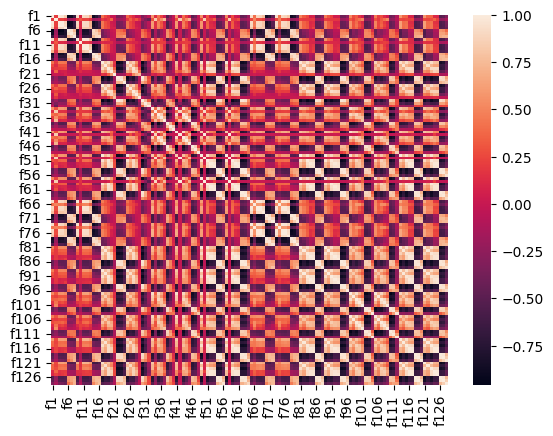

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt 

pearson_corr=X.corr(method='pearson')
pearson_corr
sns.heatmap(pearson_corr)
plt.show()

In [69]:
def drop_redundant_features(X,threshold=0.9,method='pearson'):
    corr_matrix=X.corr(method=method)
    upper_triangle=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
    
    dropped_features=[ 
        col for col in upper_triangle.columns 
        if any(upper_triangle[col]>threshold)
    ]
    print(f"{dropped_features} will be dropped")
    
    X_reduced=X.drop(columns=dropped_features)
    dropped_features=[]
    return X_reduced

In [75]:
# Feature selection
X_train_reduced = drop_redundant_features(X_train, 0.8)
X_test_reduced  = X_test[X_train_reduced.columns]

# Scaling (AFTER feature selection)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled  = scaler.transform(X_test_reduced)

# Fix labels
y_train = y_train - 1
y_test  = y_test - 1


['f3', 'f4', 'f5', 'f7', 'f8', 'f9', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f19', 'f20', 'f23', 'f25', 'f26', 'f27', 'f28', 'f30', 'f32', 'f34', 'f35', 'f36', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f49', 'f50', 'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60', 'f61', 'f62', 'f63', 'f64', 'f65', 'f67', 'f68', 'f69', 'f70', 'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80', 'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90', 'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99', 'f100', 'f101', 'f102', 'f103', 'f104', 'f105', 'f106', 'f107', 'f108', 'f109', 'f110', 'f111', 'f112', 'f113', 'f114', 'f115', 'f116', 'f117', 'f118', 'f119', 'f120', 'f121', 'f122', 'f123', 'f124', 'f125', 'f126', 'f127', 'f128'] will be dropped


### 1.Why is feature selection critical in TinyML?
- since number o feature affects the model size and mcu doesnot have a much memory
### 2. What is the impact of reducing features on: (Model size - Accuracy - Inference speed)
- size is reduced
- accuracy will decrease
- speed will increase

In [76]:
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(6, activation='softmax')
])

In [77]:
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)


In [78]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662 (2.59 KB)

 Trainable params: 662 (2.59 KB)

 Non-trainable params: 0 (0.00 B)

### 1. Why are small models preferred for TinyML?
- because mcus have low memory 
### 2. What happens if model size increases?
- the model wont be able to run

In [80]:
history = model.fit(
    X_train_scaled, y_train,
    epochs          = 30,
    batch_size      = 32,
    validation_split= 0.2,       # 20% of train set used for validation
    verbose         = 1
)



Epoch 1/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 2/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 3/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 4/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 5/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 6/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 7/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 8/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: nan - v

In [81]:
model.evaluate(X_test_scaled, y_test)

87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0000e+00 - loss: nan


[nan, 0.0]

In [83]:
print("NaNs in train:", np.isnan(X_train_scaled).sum())
print("NaNs in test :", np.isnan(X_test_scaled).sum())

print("Inf in train:", np.isinf(X_train_scaled).sum())
print("Inf in test :", np.isinf(X_test_scaled).sum())

NaNs in train: 0
NaNs in test : 0
Inf in train: 0
Inf in test : 0
